# BART Relevance Classifier — Evaluation

Compares hand labels (`rows_labeled_by_hand_3000.xlsx`) against BART predictions (`relevance_predictions_v1.csv`) and reports classifier quality metrics.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, precision_recall_fscore_support
)

sns.set_context('talk')
%matplotlib inline

BASE      = Path('.').resolve().parent
LABELS    = BASE / 'data/relevance/rows_labeled_by_hand_3000.xlsx'
PREDS_CSV = BASE / 'data/relevance/relevance_predictions_v1.csv'


## 1. Load and merge

In [3]:
labels = pd.read_excel(LABELS)[['id','Relevance','matched_tickers']]
preds  = pd.read_csv(PREDS_CSV, low_memory=False)[['id','matched_tickers',
                                                     'predicted_relevance',
                                                     'relevance_confidence']]
df = labels.merge(preds[['id','predicted_relevance','relevance_confidence']],
                  on='id', how='inner')
print(f'Matched: {len(df):,} rows')
print(f'\nLabel distribution (hand-labeled):')
print(df['Relevance'].value_counts().sort_index())
print(f'\nPrediction distribution (BART):')
print(df['predicted_relevance'].value_counts().sort_index())


Matched: 3,000 rows

Label distribution (hand-labeled):
Relevance
-1     924
 0     320
 1    1756
Name: count, dtype: int64

Prediction distribution (BART):
predicted_relevance
-1     437
 0     171
 1    2392
Name: count, dtype: int64


## 2. Metriche globali

I borderline (0) vengono gestiti in due modi:
- **Strict**: 0 → -1 (approccio conservativo)
- **Liberal**: 0 → 1 (approccio permissivo)

In [4]:
for mode, true_map, pred_map, title in [
    ('strict',  {0:-1}, {0:-1}, 'STRICT  (borderline → -1)'),
    ('liberal', {0: 1}, {0: 1}, 'LIBERAL (borderline →  1)'),
]:
    yt = df['Relevance'].replace(true_map)
    yp = df['predicted_relevance'].replace(pred_map)
    print(f'\n{"="*55}')
    print(f'  {title}')
    print('='*55)
    print(classification_report(yt, yp, labels=[1,-1],
          target_names=['Relevant (1)','Not relevant (-1)'],
          zero_division=0))
    kappa = cohen_kappa_score(yt, yp)
    print(f"Cohen's κ = {kappa:.4f}")



  STRICT  (borderline → -1)
                   precision    recall  f1-score   support

     Relevant (1)       0.67      0.92      0.78      1756
Not relevant (-1)       0.77      0.37      0.50      1244

         accuracy                           0.69      3000
        macro avg       0.72      0.65      0.64      3000
     weighted avg       0.71      0.69      0.66      3000

Cohen's κ = 0.3174

  LIBERAL (borderline →  1)
                   precision    recall  f1-score   support

     Relevant (1)       0.80      0.98      0.88      2076
Not relevant (-1)       0.91      0.43      0.59       924

         accuracy                           0.81      3000
        macro avg       0.85      0.71      0.73      3000
     weighted avg       0.83      0.81      0.79      3000

Cohen's κ = 0.4843


## 3. Confusion Matrix

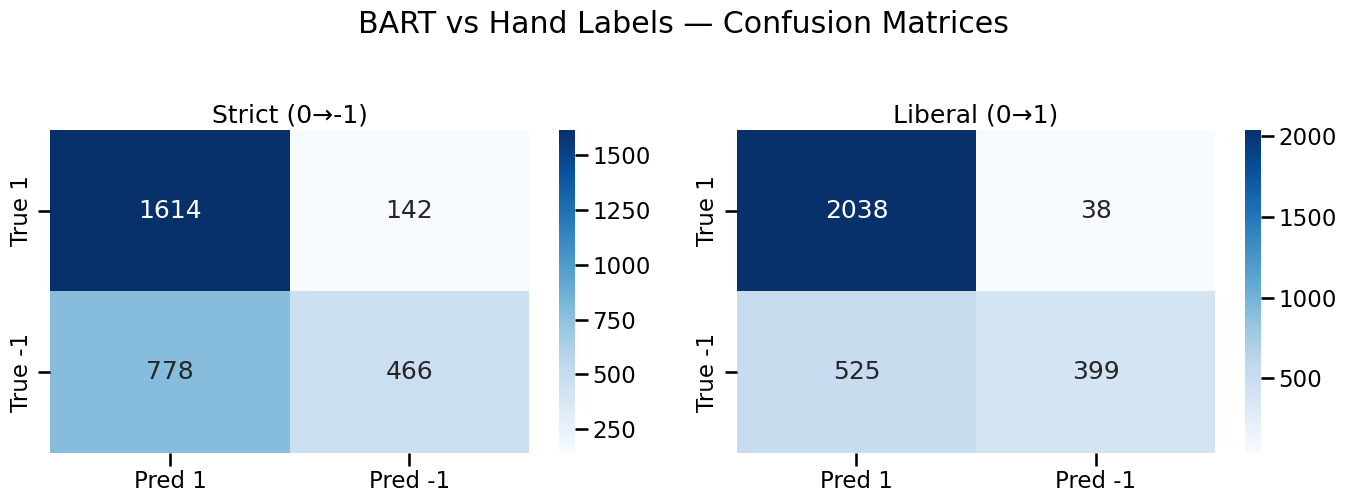

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (true_map, pred_map, title) in zip(axes, [
    ({0:-1},{0:-1},'Strict (0→-1)'),
    ({0: 1},{0: 1},'Liberal (0→1)'),
]):
    yt = df['Relevance'].replace(true_map)
    yp = df['predicted_relevance'].replace(pred_map)
    cm = confusion_matrix(yt, yp, labels=[1,-1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 1','Pred -1'],
                yticklabels=['True 1','True -1'])
    ax.set_title(title)

plt.suptitle('BART vs hand labels — confusion matrices', y=1.02)
plt.tight_layout()
plt.show()


## 4. Breakdown per stock

In [6]:
from sklearn.metrics import f1_score

rows = []
for stock in ['NVDA','AMD','PLTR']:
    sub = df[df['matched_tickers']==stock]
    yt  = sub['Relevance'].replace({0:-1})
    yp  = sub['predicted_relevance'].replace({0:-1})
    p,r,f,_ = precision_recall_fscore_support(yt, yp, labels=[1,-1],
                                               average='macro', zero_division=0)
    acc = (yt==yp).mean()
    kap = cohen_kappa_score(yt, yp)
    rows.append({'Stock':stock,'N':len(sub),'Accuracy':round(acc,3),
                 'Macro-P':round(p,3),'Macro-R':round(r,3),
                 'Macro-F1':round(f,3),"Cohen's κ":round(kap,3)})

pd.DataFrame(rows).set_index('Stock')


,N,Accuracy,Macro-P,Macro-R,Macro-F1,Cohen's κ
Stock,,,,,,
NVDA,1000,0.709,0.722,0.629,0.627,0.293
AMD,1000,0.667,0.715,0.646,0.628,0.303
PLTR,1000,0.704,0.722,0.663,0.662,0.348


## 5. Confidence vs Accuracy

Checks whether BART is well-calibrated: higher confidence should correlate with higher accuracy.

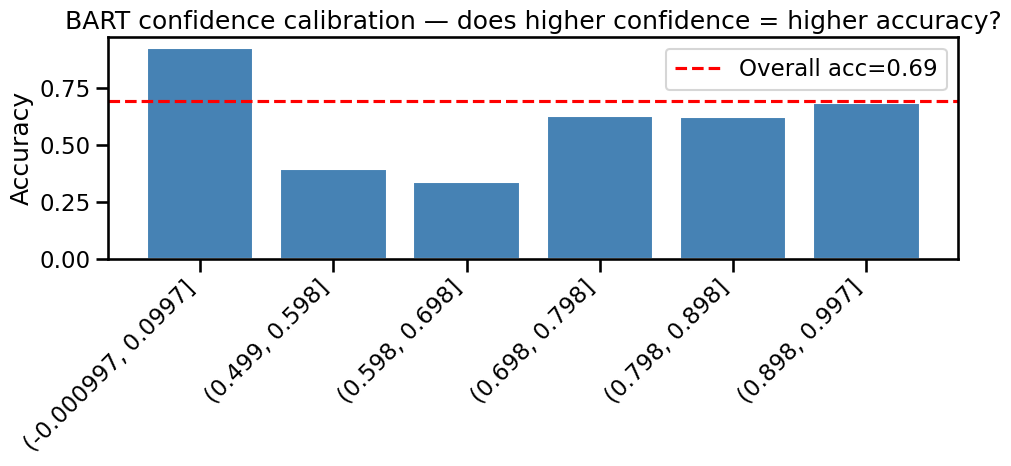

In [7]:
df['correct'] = (df['Relevance'].replace({0:-1}) == df['predicted_relevance'].replace({0:-1}))

fig, ax = plt.subplots(figsize=(10,5))
bins = pd.cut(df['relevance_confidence'], bins=10)
calib = df.groupby(bins, observed=True)['correct'].agg(['mean','count']).reset_index()
calib.columns = ['Confidence bin','Accuracy','Count']
ax.bar(range(len(calib)), calib['Accuracy'], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(calib)))
ax.set_xticklabels([str(b) for b in calib['Confidence bin']], rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Confidence calibration — higher confidence vs accuracy')
ax.axhline(df['correct'].mean(), color='red', linestyle='--', label=f'Overall acc={df["correct"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Most common errors

Comments where BART makes the most mistakes — useful for understanding model limitations.

In [8]:
# False positives: BART=1, label=-1
yt = df['Relevance'].replace({0:-1})
yp = df['predicted_relevance'].replace({0:-1})
errors = df.copy()
errors['true_strict'] = yt.values
errors['pred_strict'] = yp.values

fp = errors[(errors['true_strict']==-1) & (errors['pred_strict']==1)]
fn = errors[(errors['true_strict']==1)  & (errors['pred_strict']==-1)]

print(f'False positives (BART=1, label=-1): {len(fp)}')
print(f'False negatives (BART=-1, label=1):  {len(fn)}')
print()

# Re-join message_text for display
preds_full = pd.read_csv(PREDS_CSV, low_memory=False)[['id','message_text']]
fp_display = fp.merge(preds_full, on='id')[['matched_tickers','message_text',
                                              'relevance_confidence']].head(10)
print('Top 10 false positives:')
for _, r in fp_display.iterrows():
    print(f'  [{r.matched_tickers}] conf={r.relevance_confidence:.2f}  {str(r.message_text)[:120]}')


False positives (BART=1, label=-1): 778
False negatives (BART=-1, label=1):  142

Top 10 false positives:
  [NVDA] conf=0.86  Remindme triggered from back when I was a mod. Told you so. Looks like I was right about BBBY too You literally bought t
  [NVDA] conf=0.93  Because they are an NVIDIA reference partner.
  [NVDA] conf=0.91  Is he okay right now? I must know, hopefully he managed to pull and reinvest in Nvidia while it was down a week back and
  [NVDA] conf=0.80  Thanks to Nvidia, grandmas inheritance has finally been restored to its former glory
  [NVDA] conf=0.83  What happens when their revenue blasts above 10 billion+ as a flood of money hits them from replacing HDDs. It’s going t
  [NVDA] conf=0.95  After I posted this NVDA dropped from 150ish down to the 80s, and since then I’ve been long 10,000 shares. That’s the th
  [NVDA] conf=0.91  Make a price prediction for $NVDA on any time horizon you like. I'll do the same and we'll check back in.
  [NVDA] conf=0.78  GPU cloud pri